# This notebook shows how to find the orientation of a magnetic texture in one self-consistent run
### Import the necessary libraries

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from elkpy.structure import Structure
from elkpy.parsers import info

### The gradient of the energy with respect to a global spin rotation
Turning the input field of a self-consistent loop by $\boldsymbol\omega$ in spin space changes only the eigenvalue sum of the Harris-Foulkes energy, so by Hellmann-Feynman
$$ \frac{\partial E}{\partial\boldsymbol\omega}=\int\mathbf B_{\rm in}(\mathbf r)\times\mathbf m_{\rm out}(\mathbf r)\,d^3r $$
with $\mathbf B_{\rm in}$ the exchange-correlation field the states were solved in and $\mathbf m_{\rm out}$ the magnetization they produce. After every loop the whole texture, together with the mixer's history, is turned by $\boldsymbol\omega=-H^{-1}\,\partial E/\partial\boldsymbol\omega$, with $H$ the curvature built up by BFGS.

### L1$_0$ FePt, started 45 degrees from its easy axis
The Pt spin-orbit coupling makes $c$ the easy axis. The seed is 45 degrees from $c$ and 20 degrees from $a$, off every mirror of the crystal, so that Elk's magnetic group is $\{E, I\}$ and every orientation is allowed.

In [2]:
FEPT_AVEC = [(5.147, 0.0, 0.0), (0.0, 5.147, 0.0), (0.0, 0.0, 7.017)]  # Bohr, experimental cell


def fept(seed):
    b = 0.5 * np.asarray(seed) / np.linalg.norm(seed)  # Elk puts m antiparallel to the seed field
    return Structure(FEPT_AVEC, {"Fe": [((0, 0, 0), tuple(b))], "Pt": [((0.5, 0.5, 0.5), (0, 0, 0))]})


blocks = {"swidth": [0.005], "nempty": [8], "epspot": [1e-7], "epsengy": [1e-7],
          "reducebf": [0.5], "maxscl": [150]}  # the seed field dies away by 0.5 per loop
start = (0.6645, 0.2418, 0.7071)  # 45 degrees from c, 20 degrees from a
turned = fept(start).get_calculation("_scratch/fept_turned", spinorb=True, ngridk=(8, 8, 6),
                                     rotate_moments=True, extra_blocks=blocks)
path = turned.get_orientation_relaxation()  # one row per loop

The same start without the step, for 40 loops, with the gradient only reported (`elkpy_torque`):

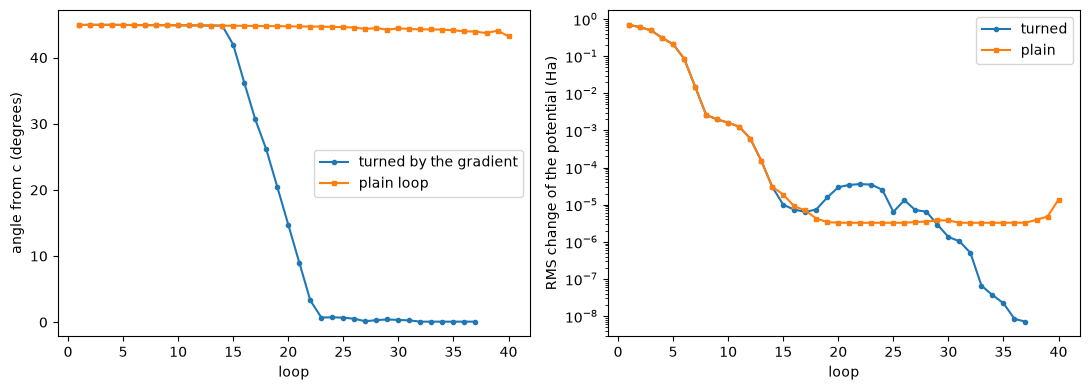

In [3]:
plain = fept(start).get_calculation("_scratch/fept_plain", spinorb=True, ngridk=(8, 8, 6),
                                    raise_on_nonconvergence=False,
                                    extra_blocks=dict(blocks, maxscl=[40], elkpy_torque=[True]))
drift = plain.get_orientation_relaxation()

def from_c(p):
    return np.degrees(np.arccos(np.abs(p["axis"][:, 2])))  # angle of the moment from c

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(path["loop"], from_c(path), "o-", ms=3, label="turned by the gradient")
left.plot(drift["loop"], from_c(drift), "s-", ms=3, label="plain loop")
left.set(xlabel="loop", ylabel="angle from c (degrees)")
left.legend(loc="center right")
right.semilogy(path["loop"], path["dv"], "o-", ms=3, label="turned")
right.semilogy(drift["loop"], drift["dv"], "s-", ms=3, label="plain")
right.set(xlabel="loop", ylabel="RMS change of the potential (Ha)")
right.legend()
fig.tight_layout()

### The gradient along the path is the anisotropy
For $E=K_1\sin^2\theta+K_2\sin^4\theta$ the gradient is $K_1\sin2\theta+4K_2\sin^3\theta\cos\theta$, which at $\theta=45^\circ$ is exactly $K_1+K_2=E(a)-E(c)$. The two reference energies come from plain runs seeded $0.06^\circ$ off $c$ and off $a$, on the same magnetic group $\{E, I\}$ as the turned run.

E(a) - E(c) = 1.871 meV per cell
energy of the turned run against the one seeded next to c: -7.2 micro-eV


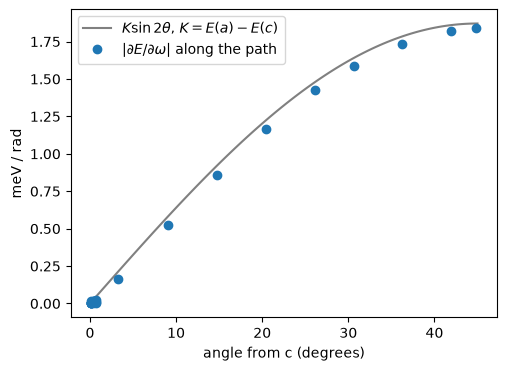

In [4]:
near_c = fept((0.001, 0.0004, 1.0)).get_calculation("_scratch/fept_near_c", spinorb=True,
                                                     ngridk=(8, 8, 6), extra_blocks=blocks)
near_a = fept((1.0, 0.0004, 0.001)).get_calculation("_scratch/fept_near_a", spinorb=True,
                                                     ngridk=(8, 8, 6), extra_blocks=blocks)
K = near_a.get_energy() - near_c.get_energy()  # Ha per cell
print(f"E(a) - E(c) = {K * 27211.386:.3f} meV per cell")

stepped = path["dv"] < 1e-4  # the loops the step acts on
theta = np.radians(from_c(path))
grid = np.linspace(0, np.pi / 4, 100)
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.plot(np.degrees(grid), K * np.sin(2 * grid) * 27211.386, color="0.5", label=r"$K\sin2\theta$, $K=E(a)-E(c)$")
ax.plot(np.degrees(theta[stepped]), np.linalg.norm(path["gradient"][stepped], axis=1) * 27211.386, "o",
        label=r"$|\partial E/\partial\omega|$ along the path")
ax.set(xlabel="angle from c (degrees)", ylabel="meV / rad")
ax.legend()
print(f"energy of the turned run against the one seeded next to c: "
      f"{(turned.get_energy() - near_c.get_energy()) * 27211.386 * 1000:.1f} micro-eV")

### The plane of a coplanar antiferromagnet: L1$_2$ Mn$_3$Ir
The three Mn moments of the T1 state lie in a (111) kagome plane, 120 degrees apart. The seed is that texture turned rigidly by 25 degrees about a generic axis, which puts the plane normal 11.7 degrees off $[111]$ and the in-plane phase off every symmetric value; the step relaxes the plane and the phase together, since the in-plane phase of this texture is not flat.

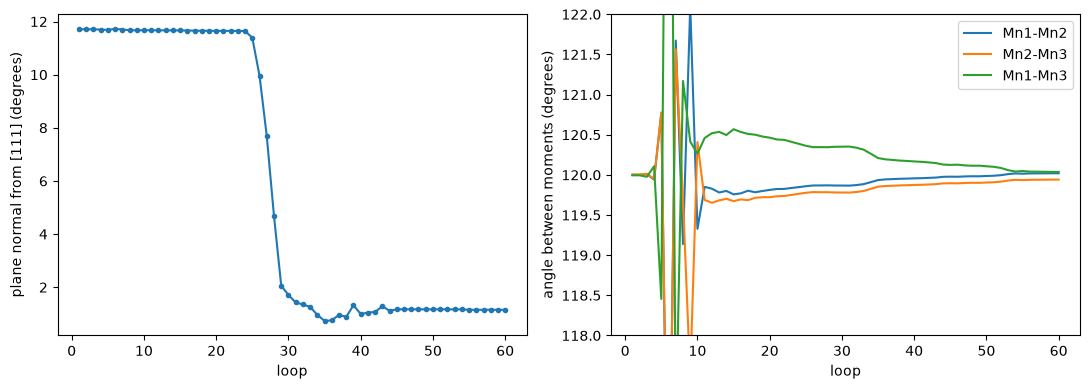

In [5]:
seed = {"Mn1": (0.0597, 0.5777, -0.8141), "Mn2": (0.7483, -0.6234, 0.2267), "Mn3": (-0.8080, 0.0457, 0.5874)}
mn3ir = Structure([(7.153, 0.0, 0.0), (0.0, 7.153, 0.0), (0.0, 0.0, 7.153)], {
    "Ir": [((0.0, 0.0, 0.0), (0.0, 0.0, 0.0))],
    "Mn": [((0.5, 0.5, 0.0), tuple(-0.5 * np.array(seed["Mn1"]))),
           ((0.5, 0.0, 0.5), tuple(-0.5 * np.array(seed["Mn2"]))),
           ((0.0, 0.5, 0.5), tuple(-0.5 * np.array(seed["Mn3"])))]})
texture = mn3ir.get_calculation("_scratch/mn3ir_turned", xc="PBE", spinorb=True, ngridk=(8, 8, 8),
                                rotate_moments=True,
                                extra_blocks=dict(blocks, maxscl=[250], epsengy=[1e-5]))  # this cell's energy moves by 1e-6 Ha per loop at dv ~ 1e-7
plane = texture.get_orientation_relaxation()
m = info.parse_moments(texture.workdir / "INFO.OUT")["muffin_tin"][:, 1:, :]  # the three Mn, per loop
u = m / np.linalg.norm(m, axis=2, keepdims=True)

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
off = np.degrees(np.arccos(np.clip(np.abs(plane["normal"] @ np.ones(3)) / np.sqrt(3), 0, 1)))
left.plot(plane["loop"], off, "o-", ms=3)
left.set(xlabel="loop", ylabel="plane normal from [111] (degrees)")
for (i, j), label in zip([(0, 1), (1, 2), (0, 2)], ["Mn1-Mn2", "Mn2-Mn3", "Mn1-Mn3"]):
    right.plot(plane["loop"], np.degrees(np.arccos(np.sum(u[:, i] * u[:, j], axis=1))), label=label)
right.set(xlabel="loop", ylabel="angle between moments (degrees)", ylim=(118, 122))
right.legend()
fig.tight_layout()

Once the plane is (111), the in-plane phase is the angle between each moment and its T1 direction $\langle 11\bar2\rangle$ (0 for the T1 state, 90 degrees for the state turned by 90 degrees about $[111]$):

In [6]:
t1 = np.array([(1, 1, -2), (1, -2, 1), (-2, 1, 1)]) / np.sqrt(6)
# about a degree: where a noncollinear texture's fixed point sits in Elk (docs/design.md #36)
print("angle of each Mn from its T1 direction (degrees):", np.degrees(np.arccos(np.sum(u[-1] * t1, axis=1))).round(2))
print("moment per Mn (Bohr magneton):", np.linalg.norm(m[-1], axis=1).round(3))
print("net moment (Bohr magneton):", info.parse_moments(texture.workdir / "INFO.OUT")["total"][-1].round(4))  # along -[111]: the weak moment T1 allows

angle of each Mn from its T1 direction (degrees): [0.84 1.48 1.12]
moment per Mn (Bohr magneton): [2.856 2.856 2.856]
net moment (Bohr magneton): [-0.0112 -0.0114 -0.0108]
